<a href="https://colab.research.google.com/github/Harikeshkaant/Trading-bot/blob/main/Final_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Episode: 1 Reward: 460658.7
Episode: 2 Reward: 518602.57
Episode: 3 Reward: 709380.58
Episode: 4 Reward: 538746.57
Episode: 5 Reward: 81989.54
Episode: 6 Reward: 390376.43
Episode: 7 Reward: 292525.05
Episode: 8 Reward: 252419.1
Episode: 9 Reward: 645230.68
Episode: 10 Reward: 209777.02
Episode: 11 Reward: 354837.71
Episode: 12 Reward: 344834.96
Episode: 13 Reward: 303370.61
Episode: 14 Reward: 70010.13
Episode: 15 Reward: 127541.85
Episode: 16 Reward: 520660.22
Episode: 17 Reward: 584134.56
Episode: 18 Reward: 298811.88
Episode: 19 Reward: 656165.35
Episode: 20 Reward: 319348.13
Episode: 21 Reward: 1049527.18
Episode: 22 Reward: 618595.82
Episode: 23 Reward: 674409.53
Episode: 24 Reward: 64134.99
Episode: 25 Reward: 279236.18
Episode: 26 Reward: 433733.29
Episode: 27 Reward: 283812.09
Episode: 28 Reward: 251458.98
Episode: 29 Reward: 285004.67
Episode: 30 Reward: 185287.7
Episode: 31 Reward: 688541.28
Episode: 32 Reward: 310738.55
Episode: 33 Reward: 328107.2
Episode: 34 Reward: 58100

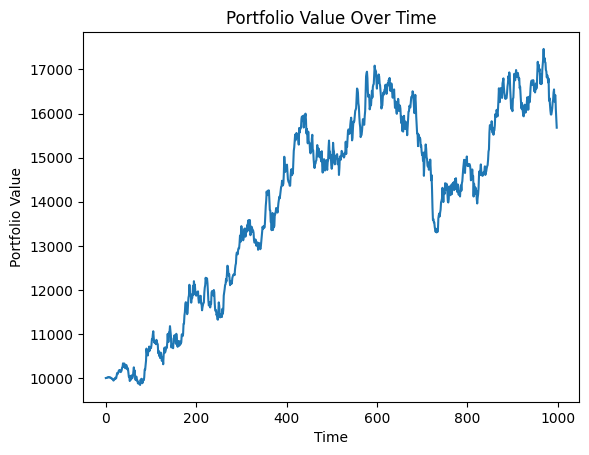

Final Portfolio Value: 15679.223806370452


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt

# -----------------------------
# 1. Generate Synthetic Stock Data
# -----------------------------
def generate_stock_data(steps=1000):
    price = 100
    prices = []
    for i in range(steps):
        drift = 0.0005
        volatility = 0.01
        shock = np.random.normal(drift, volatility)
        price = price * (1 + shock)
        prices.append(price)
    return np.array(prices)

data = generate_stock_data()

# -----------------------------
# 2. Trading Environment
# -----------------------------
class TradingEnv:
    def __init__(self, data):
        self.data = data
        self.reset()

    def reset(self):
        self.step_index = 0
        self.balance = 10000
        self.shares = 0
        return np.array([self.data[self.step_index]])

    def step(self, action):
        price = self.data[self.step_index]

        if action == 1:  # buy
            if self.balance >= price:
                self.balance -= price
                self.shares += 1
        elif action == 2:  # sell
            if self.shares > 0:
                self.balance += price
                self.shares -= 1

        self.step_index += 1
        done = self.step_index >= len(self.data)-1

        portfolio_value = self.balance + self.shares * price
        reward = portfolio_value - 10000

        # next state
        if not done:
            state = np.array([self.data[self.step_index]])
        else:
            state = np.array([price])

        return state, reward, done

# -----------------------------
# 3. Deep Q Network
# -----------------------------
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 3)
        )

    def forward(self, x):
        return self.model(x)

# -----------------------------
# 4. Training Setup
# -----------------------------
env = TradingEnv(data)
model = DQN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
gamma = 0.95
epsilon = 1.0
episodes = 50

# -----------------------------
# 5. Training Loop
# -----------------------------
for episode in range(episodes):
    state = env.reset()
    state = torch.FloatTensor(state).unsqueeze(0)  # add batch dim

    done = False
    total_reward = 0

    while not done:
        if random.random() < epsilon:
            action = random.randint(0,2)
        else:
            q_values = model(state)
            action = torch.argmax(q_values).item()

        next_state, reward, done = env.step(action)
        next_state = torch.FloatTensor(next_state).unsqueeze(0)  # add batch dim

        q_values = model(state)
        next_q = model(next_state)

        target = q_values.clone().detach()
        target[0][action] = reward + gamma * torch.max(next_q).item()  # use .item()

        loss = loss_fn(q_values, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        state = next_state
        total_reward += reward

    epsilon *= 0.995
    print("Episode:", episode+1, "Reward:", round(total_reward,2))

# -----------------------------
# 6. Evaluation
# -----------------------------
state = env.reset()
state = torch.FloatTensor(state).unsqueeze(0)
done = False
portfolio_values = []

while not done:
    q_values = model(state)
    action = torch.argmax(q_values).item()
    next_state, reward, done = env.step(action)
    state = torch.FloatTensor(next_state).unsqueeze(0)
    value = env.balance + env.shares * env.data[env.step_index]
    portfolio_values.append(value)

# -----------------------------
# 7. Plot Portfolio Performance
# -----------------------------
plt.plot(portfolio_values)
plt.title("Portfolio Value Over Time")
plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.show()
print("Final Portfolio Value:", portfolio_values[-1])

# Description

📈 Deep Reinforcement Learning Stock Trading Agent

This project implements a stock trading agent using Deep Reinforcement Learning (DQN) built with PyTorch and NumPy. The model learns how to buy, sell, or hold stocks by interacting with a simulated trading environment and maximizing portfolio profit over time.

The system first generates synthetic stock price data to simulate market behavior. A custom trading environment manages the agent’s balance, shares, and portfolio value while providing rewards based on trading performance. The agent uses a Deep Q-Network (DQN) neural network to estimate the best action at each time step.

During training, the agent explores different trading strategies using an epsilon-greedy policy, gradually shifting from random actions to learned strategies. Over multiple episodes, the neural network updates its predictions using Q-learning and backpropagation to improve decision making.

After training, the model is evaluated by running a trading simulation where the agent selects actions based on learned Q-values. The final portfolio performance is visualized using Matplotlib to show how the portfolio value changes over time.

Key Features

Synthetic stock price generation

Custom trading environment simulation

Deep Q-Network for decision making

Reinforcement learning training loop

Portfolio value evaluation and visualization

Technologies Used

PyTorch

NumPy

Matplotlib